<a href="https://colab.research.google.com/github/irpray/subtim-aset/blob/main/Kuesioner_Gaskeun_Camp_Bandung.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
from scipy.stats import wilcoxon
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

# Unggah file
uploaded = files.upload()

# Ganti 'nama_file.csv' sesuai dengan file yang Anda unggah
# Jika Excel, gunakan pd.read_excel('nama_file.xlsx')
df = pd.read_csv(list(uploaded.keys())[0])


Saving test_bandung.csv to test_bandung (1).csv


In [4]:
# Menghapus baris yang memiliki nilai kosong (jika ada)
df_clean = df.dropna()

# Menampilkan 5 data pertama untuk verifikasi
df_clean.head()

,id_responden,q1_pre,q1_post,q2_pre,q2_post,q3_pre,q3_post,q4_pre,q4_post,q5_pre,q5_post,q6_pre,q6_post
0,1,3,5,3,5,3,5,3,5,3,5,3,5
1,2,4,5,4,4,4,5,3,5,4,4,4,5
2,3,4,4,4,4,4,4,4,4,4,4,4,4
3,4,4,5,3,5,5,5,5,5,2,4,4,5
4,5,4,4,4,4,4,4,4,4,4,4,4,4


In [5]:
print("--- HASIL UJI WILCOXON PER PERTANYAAN ---")

for i in range(1, 7):
    pre_col = f'q{i}_pre'
    post_col = f'q{i}_post'

    # Hitung Wilcoxon
    stat, p = wilcoxon(df_clean[pre_col], df_clean[post_col])

    # Hitung rata-rata untuk melihat arah perubahan
    mean_pre = df_clean[pre_col].mean()
    mean_post = df_clean[post_col].mean()

    print(f"Pertanyaan {i}:")
    print(f"  Rata-rata: Pre({mean_pre:.2f}) -> Post({mean_post:.2f})")
    print(f"  P-Value: {p:.4f}")

    if p < 0.05:
        print("  Kesimpulan: Signifikan (Ada peningkatan pemahaman) ✅")
    else:
        print("  Kesimpulan: Tidak Signifikan (Pemahaman tetap/sama) ❌")
    print("-" * 40)

--- HASIL UJI WILCOXON PER PERTANYAAN ---
Pertanyaan 1:
  Rata-rata: Pre(4.24) -> Post(4.54)
  P-Value: 0.0003
  Kesimpulan: Signifikan (Ada peningkatan pemahaman) ✅
----------------------------------------
Pertanyaan 2:
  Rata-rata: Pre(4.01) -> Post(4.31)
  P-Value: 0.0011
  Kesimpulan: Signifikan (Ada peningkatan pemahaman) ✅
----------------------------------------
Pertanyaan 3:
  Rata-rata: Pre(4.31) -> Post(4.50)
  P-Value: 0.0291
  Kesimpulan: Signifikan (Ada peningkatan pemahaman) ✅
----------------------------------------
Pertanyaan 4:
  Rata-rata: Pre(4.42) -> Post(4.60)
  P-Value: 0.0408
  Kesimpulan: Signifikan (Ada peningkatan pemahaman) ✅
----------------------------------------
Pertanyaan 5:
  Rata-rata: Pre(3.97) -> Post(4.35)
  P-Value: 0.0003
  Kesimpulan: Signifikan (Ada peningkatan pemahaman) ✅
----------------------------------------
Pertanyaan 6:
  Rata-rata: Pre(4.29) -> Post(4.47)
  P-Value: 0.0787
  Kesimpulan: Tidak Signifikan (Pemahaman tetap/sama) ❌
--------

In [6]:
# Membuat kolom total di dalam Python
kolom_pre = [f'q{i}_pre' for i in range(1, 7)]
kolom_post = [f'q{i}_post' for i in range(1, 7)]

df_clean['total_pre'] = df_clean[kolom_pre].sum(axis=1)
df_clean['total_post'] = df_clean[kolom_post].sum(axis=1)

# Uji Wilcoxon untuk skor total
stat_total, p_total = wilcoxon(df_clean['total_pre'], df_clean['total_post'])

print("--- HASIL EFEKTIVITAS WORKSHOP (KESELURUHAN) ---")
print(f"P-Value Keseluruhan: {p_total:.5f}")
if p_total < 0.05:
    print("Workshop terbukti EFEKTIF meningkatkan pemahaman peserta secara umum.")
else:
    print("Workshop TIDAK memberikan perbedaan pemahaman yang signifikan secara umum.")

--- HASIL EFEKTIVITAS WORKSHOP (KESELURUHAN) ---
P-Value Keseluruhan: 0.00013
Workshop terbukti EFEKTIF meningkatkan pemahaman peserta secara umum.


/tmp/ipykernel_3669/2646167610.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Kategori', y='Skor', data=plot_data, palette="Set2")


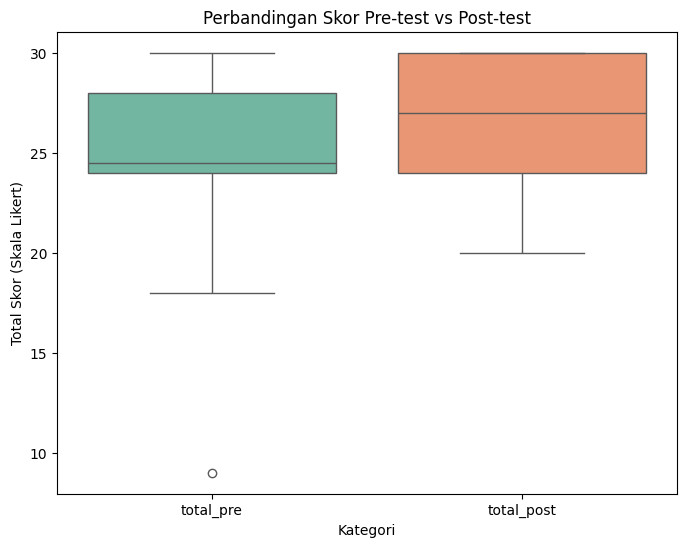

In [7]:
# Menyiapkan data untuk grafik
plot_data = df_clean[['total_pre', 'total_post']].melt(var_name='Kategori', value_name='Skor')

plt.figure(figsize=(8, 6))
sns.boxplot(x='Kategori', y='Skor', data=plot_data, palette="Set2")
plt.title('Perbandingan Skor Pre-test vs Post-test')
plt.ylabel('Total Skor (Skala Likert)')
plt.show()

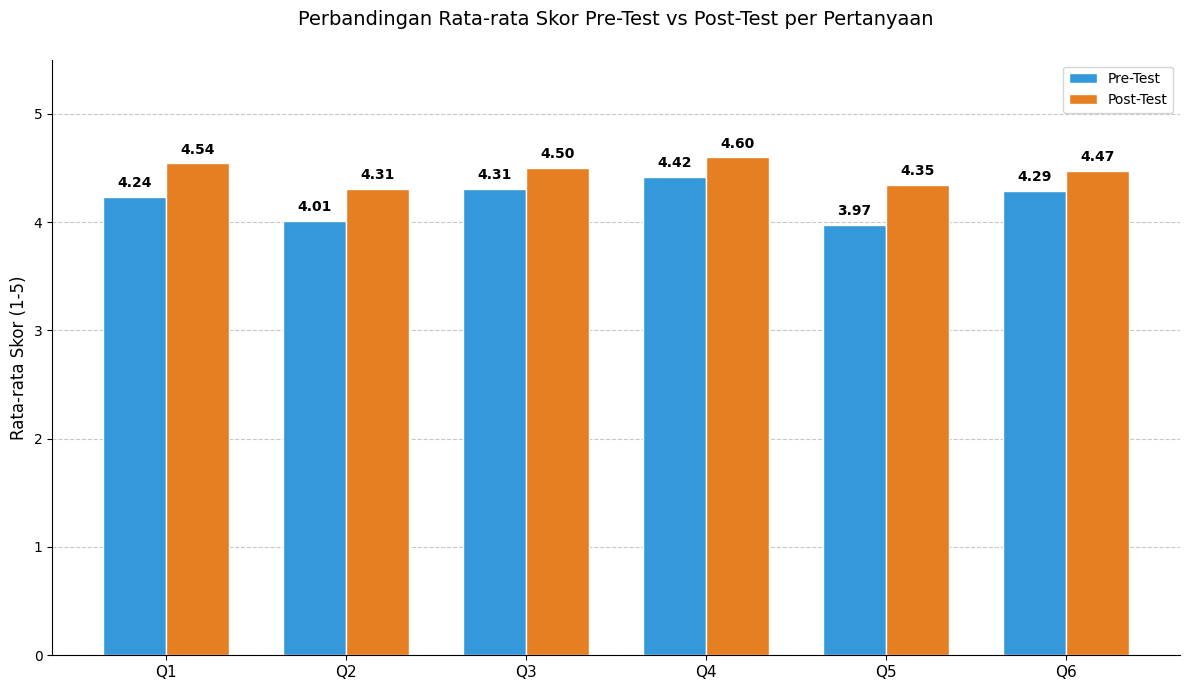

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Menghitung rata-rata untuk setiap pertanyaan (menggunakan df_clean dari langkah sebelumnya)
labels = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6']
means_pre = [df_clean[f'q{i}_pre'].mean() for i in range(1, 7)]
means_post = [df_clean[f'q{i}_post'].mean() for i in range(1, 7)]

# 2. Pengaturan posisi dan lebar bar
x = np.arange(len(labels))
width = 0.35  # Lebar masing-masing bar

fig, ax = plt.subplots(figsize=(12, 7), dpi=100)

# 3. Membuat Bar (Warna disesuaikan agar profesional: Biru dan Oranye)
rects1 = ax.bar(x - width/2, means_pre, width, label='Pre-Test', color='#3498db', edgecolor='white')
rects2 = ax.bar(x + width/2, means_post, width, label='Post-Test', color='#e67e22', edgecolor='white')

# 4. Fungsi untuk menambahkan label angka di atas setiap bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # Jarak teks di atas bar
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# 5. Mempercantik tampilan agar mirip dengan contoh
ax.set_title('Perbandingan Rata-rata Skor Pre-Test vs Post-Test per Pertanyaan', pad=25, fontsize=14)
ax.set_ylabel('Rata-rata Skor (1-5)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 5.5) # Agar ada ruang untuk angka di atas bar skala 5

# Menambahkan grid horizontal putus-putus agar mudah dibaca
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True) # Agar grid berada di belakang bar

# Menghapus garis tepi (spines) atas dan kanan agar lebih modern
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Menambahkan legenda
ax.legend(loc='upper right', frameon=True, fontsize=10)

plt.tight_layout()
plt.show()

### Deskripsi Butir Pertanyaan
Berikut adalah rincian pertanyaan yang dianalisis:
1. **Q1**: Keamanan siber (malware, judi online, manipulasi informasi).
2. **Q2**: Perbedaan misinformasi, disinformasi, dan FIMI.
3. **Q3**: Peran warga negara (verifikasi informasi & konten positif).
4. **Q4**: Permasalahan sampah sebagai ancaman serius.
5. **Q5**: Peran strategis website Indonesia.go.id.
6. **Q6**: Dorongan memproduksi konten lokal.

In [9]:
import pandas as pd

# Daftar pertanyaan lengkap
pertanyaan = [
    "Memahami keamanan siber & ancaman sosial (Judi Online, dll)",
    "Memahami perbedaan Misinformasi, Disinformasi, & FIMI",
    "Memahami peran warga negara dalam menjaga ruang siber",
    "Memahami ancaman serius permasalahan sampah",
    "Memahami peran strategis Indonesia.go.id",
    "Terdorong memproduksi konten lokal yang inspiratif"
]

# Mengumpulkan hasil dari perhitungan sebelumnya
hasil_analisis = []
for i in range(1, 7):
    pre_col = f'q{i}_pre'
    post_col = f'q{i}_post'
    stat, p = wilcoxon(df_clean[pre_col], df_clean[post_col])
    mean_pre = df_clean[pre_col].mean()
    mean_post = df_clean[post_col].mean()

    hasil_analisis.append({
        "No": f"Q{i}",
        "Topik Pertanyaan": pertanyaan[i-1],
        "Rata-rata Pre": round(mean_pre, 2),
        "Rata-rata Post": round(mean_post, 2),
        "Kenaikan": round(mean_post - mean_pre, 2),
        "P-Value": round(p, 4),
        "Signifikansi": "Signifikan ✅" if p < 0.05 else "Tidak Signifikan ❌"
    })

df_summary = pd.DataFrame(hasil_analisis)
display(df_summary)

print(f"\nKESIMPULAN UMUM:")
if p_total < 0.05:
    print(f"Secara keseluruhan, kegiatan workshop EFEKTIF meningkatkan pemahaman peserta (p={p_total:.5f}).")
    print("Hampir seluruh aspek menunjukkan peningkatan signifikan, kecuali pada aspek motivasi produksi konten (Q6) yang memerlukan pendekatan lebih lanjut.")
else:
    print("Kegiatan belum memberikan perubahan signifikan secara statistik pada skor total.")

,No,Topik Pertanyaan,Rata-rata Pre,Rata-rata Post,Kenaikan,P-Value,Signifikansi
0,Q1,Memahami keamanan siber & ancaman sosial (Judi...,4.24,4.54,0.31,0.0003,Signifikan ✅
1,Q2,"Memahami perbedaan Misinformasi, Disinformasi,...",4.01,4.31,0.29,0.0011,Signifikan ✅
2,Q3,Memahami peran warga negara dalam menjaga ruan...,4.31,4.50,0.19,0.0291,Signifikan ✅
3,Q4,Memahami ancaman serius permasalahan sampah,4.42,4.60,0.18,0.0408,Signifikan ✅
4,Q5,Memahami peran strategis Indonesia.go.id,3.97,4.35,0.38,0.0003,Signifikan ✅
5,Q6,Terdorong memproduksi konten lokal yang inspir...,4.29,4.47,0.18,0.0787,Tidak Signifikan ❌



KESIMPULAN UMUM:
Secara keseluruhan, kegiatan workshop EFEKTIF meningkatkan pemahaman peserta (p=0.00013).
Hampir seluruh aspek menunjukkan peningkatan signifikan, kecuali pada aspek motivasi produksi konten (Q6) yang memerlukan pendekatan lebih lanjut.
